In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from benchmark.examples.gaussian.datasets.datasets import GetDatasets 

In [2]:
RNG=np.random.default_rng(2025)
num_dims=30
num_obs=50
likelihood_std=1
student_df=5

In [3]:
import pickle
# read observation datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_m1  = load_pickle("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets/m1.pkl")
datasets_m2 = load_pickle("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets/m2.pkl")
datasets_m3   = load_pickle("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets/m3.pkl")
datasets_m4   = load_pickle("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets/m4.pkl")

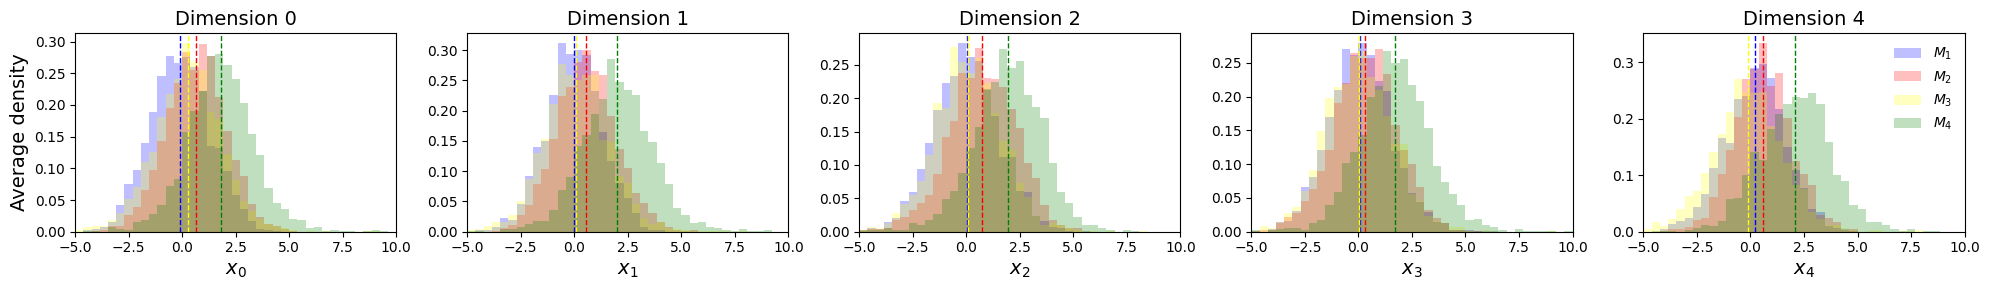

In [4]:
def average_histogram(datasets, key, dim, bins, max_datasets=50):
    histograms = []
    means = []

    for d in datasets[:max_datasets]:
        values = np.asarray(d[key])[:, dim]
        hist, _ = np.histogram(values, bins=bins, density=True)
        histograms.append(hist)
        means.append(values.mean())

    if not histograms:
        raise ValueError("No datasets available for averaging.")

    histograms = np.asarray(histograms)
    return histograms.mean(axis=0), np.mean(means)


def plot_observation_distributions(datasets_m1, datasets_m2, datasets_m3, num_dims, max_datasets=50):
    D =5

    fig, axes = plt.subplots(1, D, figsize=(4 * D, 3), sharey=False)

    x_min, x_max = -5, 10
    bins = np.linspace(x_min, x_max, 40)

    model_specs = [
        (datasets_m1, r"$M_1$", "blue"),
        (datasets_m2, r"$M_2$", "red"),
        (datasets_m3, r"$M_3$", "yellow"),
        (datasets_m4, r"$M_4$", "green"),
    ]

    for dim in range(D):
        ax = axes[dim] if D > 1 else axes

        for datasets, label, color in model_specs:
            avg_hist, avg_mean = average_histogram(
                datasets,
                key="x",
                dim=dim,
                bins=bins,
                max_datasets=max_datasets,
            )

            ax.stairs(avg_hist, bins, fill=True, alpha=0.25, color=color, label=label)
            ax.axvline(avg_mean, linestyle="--", linewidth=1, color=color)

        ax.set_xlim(x_min, x_max)
        ax.set_title(f"Dimension {dim}", fontsize=14)
        ax.set_xlabel(rf"$x_{dim}$", fontsize=14)

        if dim == 0:
            ax.set_ylabel("Average density", fontsize=14)

    legend_ax = axes[-1] if D > 1 else axes
    legend_ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


plot_observation_distributions(datasets_m1, datasets_m2, datasets_m3, num_dims, max_datasets=50)
